# Land Cover Analysis

This notebook analyzes land cover data from Algeria and Tunisia using the shapefile datasets.

## Analysis Structure

**Section 0: Setup & Imports**
- Configure multi-threading
- Import required libraries

**Section 1: Data Loading & Understanding**
- Load shapefiles
- Examine dataset structure
- Understand features and geometry types

**Section 2: Exploratory Data Analysis**
- Univariate analysis (distribution of land cover types)
- Bivariate analysis (relationships between features)
- Geographic visualizations

**Section 3: Data Preprocessing**
- Handle duplicates
- Check for missing values
- Data quality validation

**Section 4: Geographic Visualization**
- Plot Algeria and Tunisia land cover maps
- Visualize boundaries

In [1]:
# Add project root to path and import config
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import configure_threading

configure_threading()

Threading configured to use up to 12 CPU cores.


12

In [2]:
# Import required libraries and config paths
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import ALGERIA_SHP, TUNISIA_SHP, ALGERIA_LC_DIR, TUNISIA_LC_DIR

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Set plotting style using seaborn
sns.set_theme(style='darkgrid', palette='husl')

# Load the shapefiles using config paths
algeria_lc = gpd.read_file(ALGERIA_SHP)
tunisia_lc = gpd.read_file(TUNISIA_LC_DIR / 'tun_gc_adg.shp')

# Rename land cover columns to a common name for consistency
# Algeria uses 'LCCCODE', Tunisia uses 'LCCCode'
algeria_lc = algeria_lc.rename(columns={'LCCCODE': 'landcover'})
tunisia_lc = tunisia_lc.rename(columns={'LCCCode': 'landcover'})

# Harmonize CRS so boundaries align
if tunisia_lc.crs != algeria_lc.crs:
    tunisia_lc = tunisia_lc.to_crs(algeria_lc.crs)

# =====================================================
# Land Cover Label Mapping & Realistic Color Palette
# =====================================================
# CORRECTED mapping based on geographic distribution analysis
# Codes 0011, 6001, 6004 are dominant in Sahara = desert types
LC_LABELS = {
    # Desert/Barren types (dominant in Sahara)
    '0011': 'Bare Land',              # Most common in Sahara - sandy/rocky desert
    '6001': 'Sandy Desert',           # Erg (sand dunes)
    '6004': 'Rocky Desert',           # Reg/Hamada (rocky desert)
    
    # Vegetation types
    '7001 // 8001': 'Cropland',
    '21497-121340': 'Sparse Vegetation',
    '21450': 'Shrubland',
    '11498': 'Forest',
    '21499-121340': 'Steppe',
    '21446 // 21450-121340 / 21454': 'Mixed Vegetation',
    '21496-121340 // 21497-129401': 'Sparse Shrub',
    '41638-60686-R2 // 41898-60686-R2': 'Agriculture',
    '21518': 'Dense Shrub',
    '21454 // 21446 // 21450': 'Savanna',
    '11490 // 11494': 'Deciduous Forest',
    '21454 // 21465': 'Open Shrub',
    '6020': 'Oasis Vegetation',
    
    # Water types
    '0004 // 0003': 'Water',
    '0003 / 0004': 'Wetland',
    '0010': 'Lake/River',
    '21497-15045': 'Salt Flat',
    
    # Urban types
    '20049 // 20058': 'Urban/Built-up',
    '20058': 'Built-up',
    '20049 / 20058': 'Urban Mix',
}

# Realistic color palette for land cover types
LC_COLORS = {
    'Bare Land': '#D2B48C',
    'Sandy Desert': '#F4E0B9',
    'Rocky Desert': '#C4A484',
    'Cropland': '#90EE90',
    'Sparse Vegetation': '#BDB76B',
    'Shrubland': '#8FBC8F',
    'Forest': '#228B22',
    'Steppe': '#9ACD32',
    'Mixed Vegetation': '#6B8E23',
    'Sparse Shrub': '#DAA520',
    'Agriculture': '#7CFC00',
    'Dense Shrub': '#556B2F',
    'Savanna': '#F0E68C',
    'Deciduous Forest': '#32CD32',
    'Open Shrub': '#BDB76B',
    'Oasis Vegetation': '#00FA9A',
    'Water': '#1E90FF',
    'Wetland': '#4682B4',
    'Lake/River': '#4169E1',
    'Salt Flat': '#E0E0E0',
    'Urban/Built-up': '#808080',
    'Built-up': '#696969',
    'Urban Mix': '#A9A9A9',
}

def get_lc_label(code):
    """Get readable label for land cover code."""
    if code in LC_LABELS:
        return LC_LABELS[code]
    # Simplify long codes
    code_str = str(code)
    if '//' in code_str:
        return code_str.split('//')[0].strip()[:12]
    if '-' in code_str:
        return code_str.split('-')[0].strip()[:12]
    return code_str[:15]

def get_lc_color(label):
    """Get color for land cover label."""
    if label in LC_COLORS:
        return LC_COLORS[label]
    # Default color for unknown types
    return '#CCCCCC'

print("✅ Shapefiles loaded and color mapping defined")


✅ Shapefiles loaded and color mapping defined


---
## Section 1: Data Loading & Understanding

In [3]:
print("="*70)
print("DATASET STRUCTURE ANALYSIS")
print("="*70)

# Algeria Dataset Analysis
print("\n" + "="*70)
print("ALGERIA LAND COVER DATASET")
print("="*70)
print(f"\nShape: {algeria_lc.shape}")
print(f"Columns: {algeria_lc.columns.tolist()}")
print(f"CRS: {algeria_lc.crs}")
print(f"Geometry Type: {algeria_lc.geom_type.unique().tolist()}")
print(f"\nData Types:")
print(algeria_lc.dtypes)
print(f"\nFirst 5 rows:")
print(algeria_lc.head())
print(f"\nBasic Statistics:")
print(algeria_lc.describe(include='all'))

# Tunisia Dataset Analysis
print("\n" + "="*70)
print("TUNISIA LAND COVER DATASET")
print("="*70)
print(f"\nShape: {tunisia_lc.shape}")
print(f"Columns: {tunisia_lc.columns.tolist()}")
print(f"CRS: {tunisia_lc.crs}")
print(f"Geometry Type: {tunisia_lc.geom_type.unique().tolist()}")
print(f"\nData Types:")
print(tunisia_lc.dtypes)
print(f"\nFirst 5 rows:")
print(tunisia_lc.head())
print(f"\nBasic Statistics:")
print(tunisia_lc.describe(include='all'))

print("\n" + "="*70)
print("✓ Dataset structure analysis complete!")
print("="*70)

DATASET STRUCTURE ANALYSIS

ALGERIA LAND COVER DATASET

Shape: (386454, 5)
Columns: ['ID', 'GRIDCODE', 'AREA', 'landcover', 'geometry']
CRS: EPSG:4326
Geometry Type: ['Polygon']

Data Types:
ID              int32
GRIDCODE        int32
AREA          float64
landcover      object
geometry     geometry
dtype: object

First 5 rows:
   ID  GRIDCODE          AREA     landcover  \
0   4       210  6.228187e+06  7001 // 8001   
1   2       210  6.242408e+06  7001 // 8001   
2   1       210  1.482995e+06  7001 // 8001   
3   8        50  4.590841e+08  21497-121340   
4  13       210  6.371533e+06  7001 // 8001   

                                            geometry  
0  POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...  
1  POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...  
2  POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7...  
3  POLYGON ((6.12361 36.68472, 6.12361 36.69306, ...  
4  POLYGON ((6.26181 37.02361, 6.26193 37.02514, ...  

Basic Statistics:
                   ID       GRIDCODE  

---
## Section 2: Exploratory Data Analysis

### 2.1 Univariate Analysis

UNIVARIATE ANALYSIS - LAND COVER DISTRIBUTION

--- Algeria Land Cover Distribution ---
landcover
0011                                168143
6001                                 57050
20049 // 20058                       39532
6004                                 25243
0003 / 0004                          23115
0004 // 0003                         18023
20058                                15922
21446 // 21450-121340 / 21454        11903
11498                                11155
21450                                 7313
21518                                 5127
21497-121340                          2099
21499-121340                           770
21454 // 21446 // 21450                392
7001 // 8001                           288
11490 // 11494                         228
0010                                    86
21497-15045                             48
21496-121340 // 21497-129401             8
6020                                     5
41638-60686-R2 // 41898-60686-R2         3


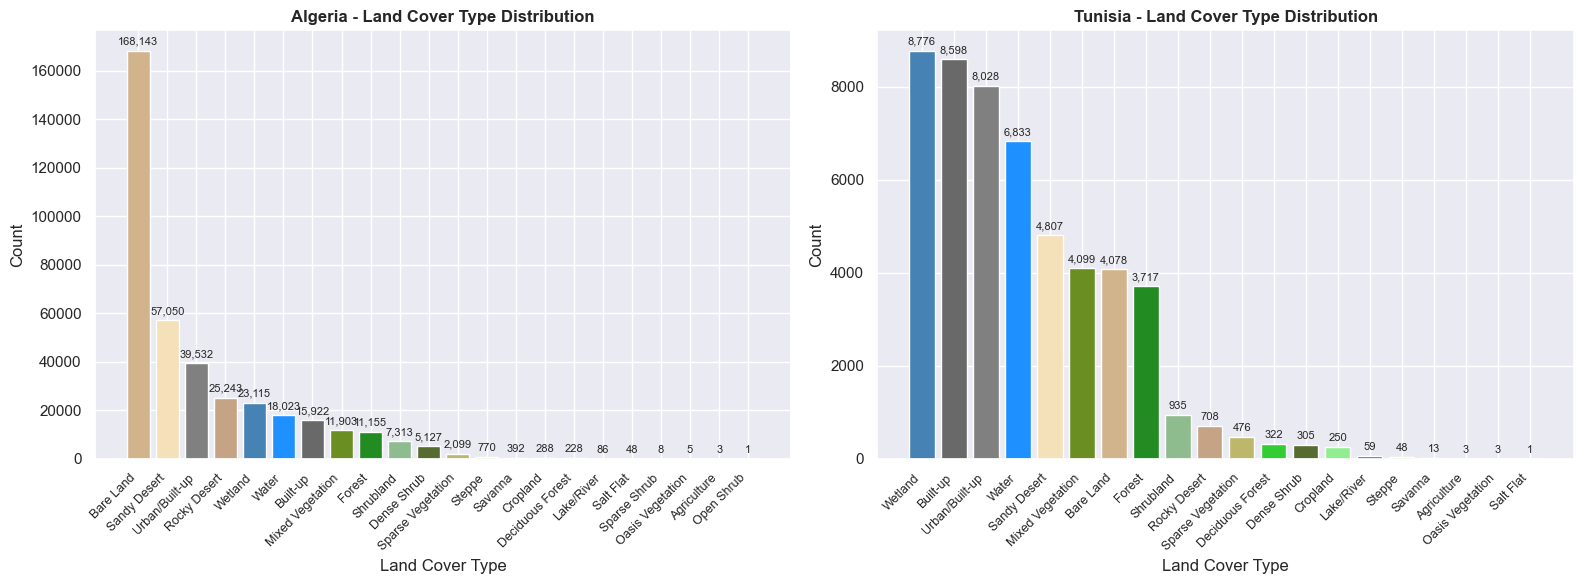


✓ Univariate analysis complete!


In [4]:
print("="*70)
print("UNIVARIATE ANALYSIS - LAND COVER DISTRIBUTION")
print("="*70)

# Algeria Land Cover Distribution
print("\n--- Algeria Land Cover Distribution ---")
algeria_lc_counts = algeria_lc['landcover'].value_counts()
print(algeria_lc_counts)

# Create readable labels for plotting
algeria_labels = [get_lc_label(code) for code in algeria_lc_counts.index]
algeria_colors = [get_lc_color(label) for label in algeria_labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Algeria bar plot
ax1 = axes[0]
bars1 = ax1.bar(range(len(algeria_lc_counts)), algeria_lc_counts.values, color=algeria_colors)
ax1.set_xticks(range(len(algeria_lc_counts)))
ax1.set_xticklabels(algeria_labels, rotation=45, ha='right', fontsize=9)
ax1.set_title('Algeria - Land Cover Type Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Land Cover Type')
ax1.set_ylabel('Count')
# Add value labels on bars
for bar, val in zip(bars1, algeria_lc_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(algeria_lc_counts)*0.01, 
             f'{val:,}', ha='center', va='bottom', fontsize=8)

# Tunisia Land Cover Distribution
print("\n--- Tunisia Land Cover Distribution ---")
tunisia_lc_counts = tunisia_lc['landcover'].value_counts()
print(tunisia_lc_counts)

# Create readable labels for plotting
tunisia_labels = [get_lc_label(code) for code in tunisia_lc_counts.index]
tunisia_colors = [get_lc_color(label) for label in tunisia_labels]

ax2 = axes[1]
bars2 = ax2.bar(range(len(tunisia_lc_counts)), tunisia_lc_counts.values, color=tunisia_colors)
ax2.set_xticks(range(len(tunisia_lc_counts)))
ax2.set_xticklabels(tunisia_labels, rotation=45, ha='right', fontsize=9)
ax2.set_title('Tunisia - Land Cover Type Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Land Cover Type')
ax2.set_ylabel('Count')
# Add value labels on bars
for bar, val in zip(bars2, tunisia_lc_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(tunisia_lc_counts)*0.01, 
             f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Univariate analysis complete!")
print("="*70)

LAND COVER PROPORTIONS - PIE CHARTS


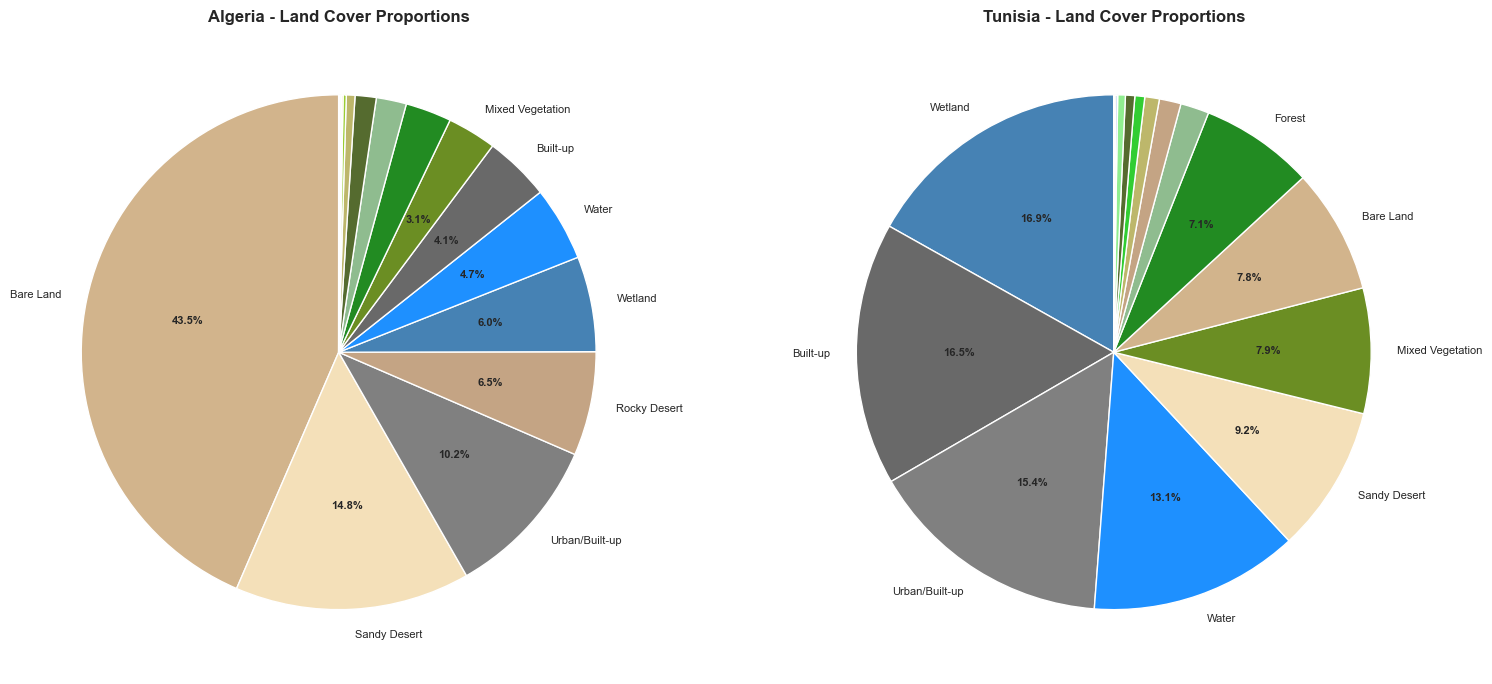


✓ Pie charts generated!


In [5]:
# Pie charts for land cover proportions
print("="*70)
print("LAND COVER PROPORTIONS - PIE CHARTS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Threshold for displaying labels (percentage)
label_threshold = 3.0

# Algeria pie chart
ax1 = axes[0]
algeria_proportions = algeria_lc['landcover'].value_counts()
algeria_pie_labels = [get_lc_label(code) for code in algeria_proportions.index]
algeria_pie_colors = [get_lc_color(label) for label in algeria_pie_labels]
algeria_total = algeria_proportions.sum()

wedges1, texts1, autotexts1 = ax1.pie(algeria_proportions.values, 
                                       labels=algeria_pie_labels,
                                       autopct='%1.1f%%',
                                       colors=algeria_pie_colors,
                                       startangle=90)
ax1.set_title('Algeria - Land Cover Proportions', fontsize=12, fontweight='bold')

# Hide labels for small slices
for i, (text, autotext) in enumerate(zip(texts1, autotexts1)):
    pct = 100 * algeria_proportions.values[i] / algeria_total
    if pct < label_threshold:
        text.set_text('')
        autotext.set_text('')
    else:
        plt.setp(autotext, size=8, fontweight='bold')
        plt.setp(text, size=8)

# Tunisia pie chart
ax2 = axes[1]
tunisia_proportions = tunisia_lc['landcover'].value_counts()
tunisia_pie_labels = [get_lc_label(code) for code in tunisia_proportions.index]
tunisia_pie_colors = [get_lc_color(label) for label in tunisia_pie_labels]
tunisia_total = tunisia_proportions.sum()

wedges2, texts2, autotexts2 = ax2.pie(tunisia_proportions.values, 
                                       labels=tunisia_pie_labels,
                                       autopct='%1.1f%%',
                                       colors=tunisia_pie_colors,
                                       startangle=90)
ax2.set_title('Tunisia - Land Cover Proportions', fontsize=12, fontweight='bold')

# Hide labels for small slices
for i, (text, autotext) in enumerate(zip(texts2, autotexts2)):
    pct = 100 * tunisia_proportions.values[i] / tunisia_total
    if pct < label_threshold:
        text.set_text('')
        autotext.set_text('')
    else:
        plt.setp(autotext, size=8, fontweight='bold')
        plt.setp(text, size=8)

plt.tight_layout()
plt.show()

print("\n✓ Pie charts generated!")
print("="*70)

### 2.2 Bivariate Analysis

BIVARIATE ANALYSIS - GEOGRAPHIC DISTRIBUTION BY LAND COVER

--- Extracting coordinates for analysis ---


C:\Users\Azur\AppData\Local\Temp\ipykernel_13056\2482730969.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  algeria_lc['centroid_x'] = algeria_lc.geometry.centroid.x
C:\Users\Azur\AppData\Local\Temp\ipykernel_13056\2482730969.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  algeria_lc['centroid_y'] = algeria_lc.geometry.centroid.y
C:\Users\Azur\AppData\Local\Temp\ipykernel_13056\2482730969.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  tunisia_lc['centroid_x'] = tunisia_lc.geometry.centroid.x
C:\Users\Azur\AppData\Local\Temp\ipykernel_13056\2482730969.py:1

Algeria coordinates extracted: 386454 points
Tunisia coordinates extracted: 52059 points


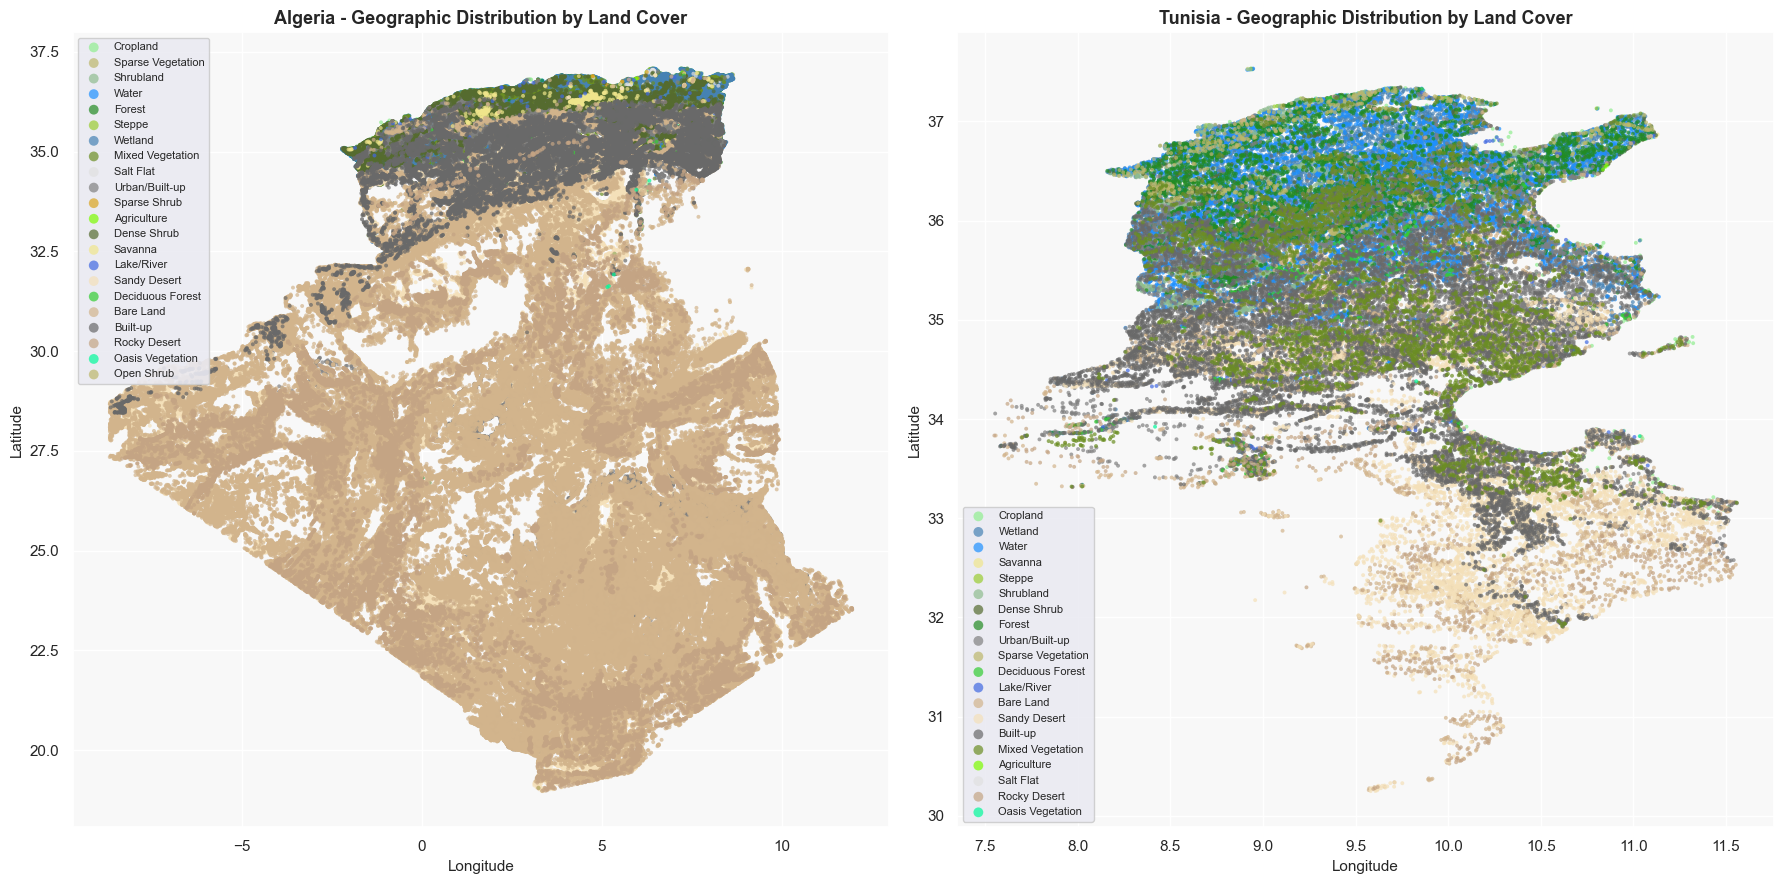


✓ Geographic distribution analysis complete!


In [6]:
print("="*70)
print("BIVARIATE ANALYSIS - GEOGRAPHIC DISTRIBUTION BY LAND COVER")
print("="*70)

# Extract coordinates from geometry for bivariate analysis
print("\n--- Extracting coordinates for analysis ---")

# Algeria coordinates
if algeria_lc.geom_type.iloc[0] in ['Polygon', 'MultiPolygon']:
    algeria_lc['centroid_x'] = algeria_lc.geometry.centroid.x
    algeria_lc['centroid_y'] = algeria_lc.geometry.centroid.y
else:
    algeria_lc['centroid_x'] = algeria_lc.geometry.x
    algeria_lc['centroid_y'] = algeria_lc.geometry.y

# Tunisia coordinates  
if tunisia_lc.geom_type.iloc[0] in ['Polygon', 'MultiPolygon']:
    tunisia_lc['centroid_x'] = tunisia_lc.geometry.centroid.x
    tunisia_lc['centroid_y'] = tunisia_lc.geometry.centroid.y
else:
    tunisia_lc['centroid_x'] = tunisia_lc.geometry.x
    tunisia_lc['centroid_y'] = tunisia_lc.geometry.y

print(f"Algeria coordinates extracted: {len(algeria_lc)} points")
print(f"Tunisia coordinates extracted: {len(tunisia_lc)} points")

# Scatter plot: Geographic distribution by land cover type
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Algeria scatter plot
ax1 = axes[0]
for lc_code in algeria_lc['landcover'].unique():
    subset = algeria_lc[algeria_lc['landcover'] == lc_code]
    label = get_lc_label(lc_code)
    color = get_lc_color(label)
    ax1.scatter(subset['centroid_x'], subset['centroid_y'], 
                label=label, alpha=0.7, s=8, c=color, edgecolors='none')
ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.set_title('Algeria - Geographic Distribution by Land Cover', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8, markerscale=2.5, framealpha=0.9, ncol=1)
ax1.set_facecolor('#f8f8f8')

# Tunisia scatter plot
ax2 = axes[1]
for lc_code in tunisia_lc['landcover'].unique():
    subset = tunisia_lc[tunisia_lc['landcover'] == lc_code]
    label = get_lc_label(lc_code)
    color = get_lc_color(label)
    ax2.scatter(subset['centroid_x'], subset['centroid_y'], 
                label=label, alpha=0.7, s=8, c=color, edgecolors='none')
ax2.set_xlabel('Longitude', fontsize=11)
ax2.set_ylabel('Latitude', fontsize=11)
ax2.set_title('Tunisia - Geographic Distribution by Land Cover', fontsize=13, fontweight='bold')
ax2.legend(loc='lower left', fontsize=8, markerscale=2.5, framealpha=0.9, ncol=1)
ax2.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.show()

print("\n✓ Geographic distribution analysis complete!")
print("="*70)

COMPARATIVE ANALYSIS - ALGERIA VS TUNISIA (TOP 9)

Algeria land cover types: 22
Tunisia land cover types: 20
Common types: 20
Top 9 features for comparison: ['Bare Land', 'Sandy Desert', 'Urban/Built-up', 'Wetland', 'Rocky Desert', 'Water', 'Built-up', 'Mixed Vegetation', 'Forest']


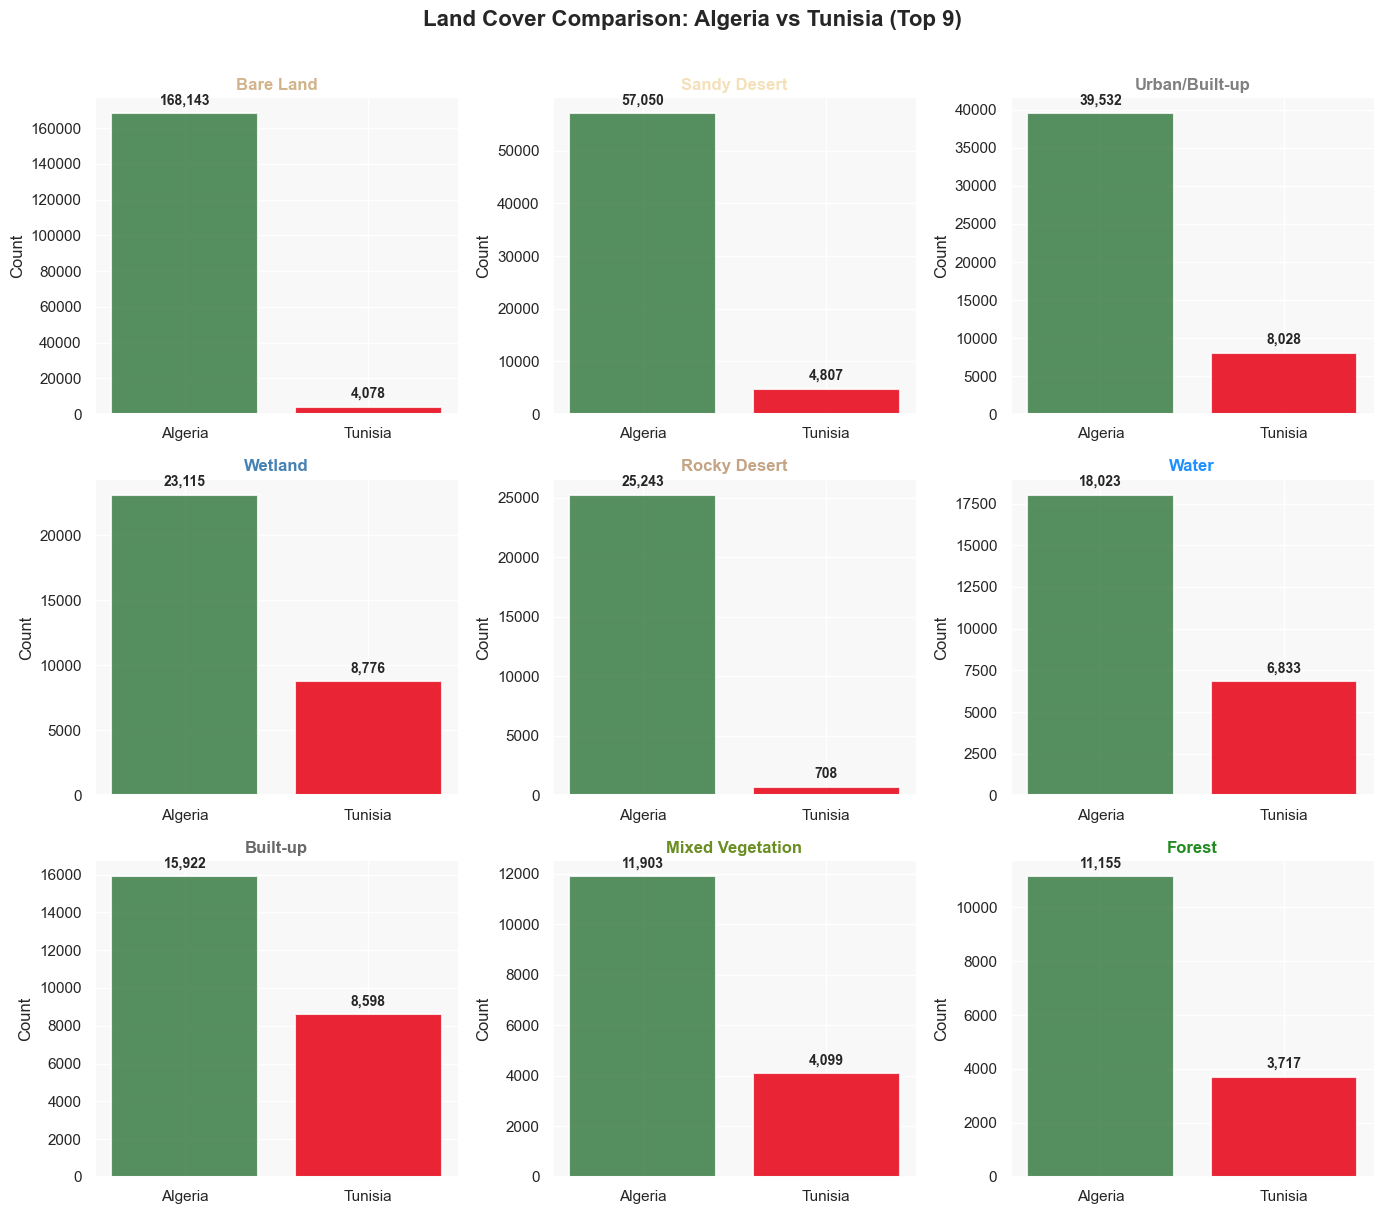


✓ Comparative analysis complete!


In [7]:
# Comparative analysis: Land cover comparison between Algeria and Tunisia
print("="*70)
print("COMPARATIVE ANALYSIS - ALGERIA VS TUNISIA (TOP 9)")
print("="*70)

# Combine datasets for comparison
algeria_lc['country'] = 'Algeria'
tunisia_lc['country'] = 'Tunisia'

# Get common land cover types
algeria_types = set(algeria_lc['landcover'].unique())
tunisia_types = set(tunisia_lc['landcover'].unique())
common_types = algeria_types.intersection(tunisia_types)

print(f"\nAlgeria land cover types: {len(algeria_types)}")
print(f"Tunisia land cover types: {len(tunisia_types)}")
print(f"Common types: {len(common_types)}")

# Create comparison data for common types
comparison_data = []
for lc_code in common_types:
    label = get_lc_label(lc_code)
    alg_count = algeria_lc[algeria_lc['landcover'] == lc_code].shape[0]
    tun_count = tunisia_lc[tunisia_lc['landcover'] == lc_code].shape[0]
    comparison_data.append({
        'label': label,
        'algeria': alg_count,
        'tunisia': tun_count,
        'total': alg_count + tun_count,
        'color': get_lc_color(label)
    })

# Sort by total count and keep only top 9
comparison_data.sort(key=lambda x: x['total'], reverse=True)
comparison_data = comparison_data[:9]

print(f"Top 9 features for comparison: {[d['label'] for d in comparison_data]}")

# Create 3x3 grid for top 9 land cover types
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, data in enumerate(comparison_data):
    ax = axes[i]
    countries = ['Algeria', 'Tunisia']
    counts = [data['algeria'], data['tunisia']]
    colors = ['#3A7D44', '#E70013']  # Green for Algeria, Red for Tunisia
    
    bars = ax.bar(countries, counts, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    
    # Add value labels on bars
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.02,
                f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{data["label"]}', fontsize=12, fontweight='bold', color=data['color'])
    ax.set_ylabel('Count')
    ax.set_facecolor('#f8f8f8')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Land Cover Comparison: Algeria vs Tunisia (Top 9)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n✓ Comparative analysis complete!")
print("="*70)

---
## Section 3: Data Preprocessing

In [8]:
print("="*70)
print("DATA PREPROCESSING")
print("="*70)

# =====================================================
# 3.1 Check for Missing Values
# =====================================================
print("\n--- 3.1 Missing Values Analysis ---")

print("\nAlgeria Dataset - Missing Values:")
algeria_missing = algeria_lc.isnull().sum()
print(algeria_missing[algeria_missing > 0] if algeria_missing.sum() > 0 else "  No missing values")

print("\nTunisia Dataset - Missing Values:")
tunisia_missing = tunisia_lc.isnull().sum()
print(tunisia_missing[tunisia_missing > 0] if tunisia_missing.sum() > 0 else "  No missing values")

# =====================================================
# 3.2 Check for Duplicates
# =====================================================
print("\n--- 3.2 Duplicate Analysis ---")

# Check for duplicate geometries (based on coordinates)
algeria_duplicates = algeria_lc.duplicated(subset=['centroid_x', 'centroid_y']).sum()
tunisia_duplicates = tunisia_lc.duplicated(subset=['centroid_x', 'centroid_y']).sum()

print(f"\nAlgeria - Duplicate geometries: {algeria_duplicates} ({algeria_duplicates/len(algeria_lc)*100:.2f}%)")
print(f"Tunisia - Duplicate geometries: {tunisia_duplicates} ({tunisia_duplicates/len(tunisia_lc)*100:.2f}%)")

# Remove duplicates if any
if algeria_duplicates > 0:
    algeria_lc_clean = algeria_lc.drop_duplicates(subset=['centroid_x', 'centroid_y'], keep='first')
    print(f"  Algeria: Removed {algeria_duplicates} duplicates → {len(algeria_lc_clean)} records remaining")
else:
    algeria_lc_clean = algeria_lc.copy()
    print(f"  Algeria: No duplicates to remove")

if tunisia_duplicates > 0:
    tunisia_lc_clean = tunisia_lc.drop_duplicates(subset=['centroid_x', 'centroid_y'], keep='first')
    print(f"  Tunisia: Removed {tunisia_duplicates} duplicates → {len(tunisia_lc_clean)} records remaining")
else:
    tunisia_lc_clean = tunisia_lc.copy()
    print(f"  Tunisia: No duplicates to remove")

# =====================================================
# 3.3 Validate Geometry
# =====================================================
print("\n--- 3.3 Geometry Validation ---")

# Check for invalid geometries
algeria_invalid = (~algeria_lc_clean.geometry.is_valid).sum()
tunisia_invalid = (~tunisia_lc_clean.geometry.is_valid).sum()

print(f"Algeria - Invalid geometries: {algeria_invalid}")
print(f"Tunisia - Invalid geometries: {tunisia_invalid}")

# Fix invalid geometries if any
if algeria_invalid > 0:
    algeria_lc_clean['geometry'] = algeria_lc_clean.geometry.buffer(0)
    print(f"  Algeria: Fixed {algeria_invalid} invalid geometries using buffer(0)")

if tunisia_invalid > 0:
    tunisia_lc_clean['geometry'] = tunisia_lc_clean.geometry.buffer(0)
    print(f"  Tunisia: Fixed {tunisia_invalid} invalid geometries using buffer(0)")

# =====================================================
# 3.4 Check for Outliers in Coordinates
# =====================================================
print("\n--- 3.4 Coordinate Outlier Analysis ---")

def check_coordinate_outliers(gdf, name):
    """Check for coordinate outliers using IQR method."""
    x_q1, x_q3 = gdf['centroid_x'].quantile([0.25, 0.75])
    y_q1, y_q3 = gdf['centroid_y'].quantile([0.25, 0.75])
    
    x_iqr = x_q3 - x_q1
    y_iqr = y_q3 - y_q1
    
    x_outliers = ((gdf['centroid_x'] < x_q1 - 1.5*x_iqr) | (gdf['centroid_x'] > x_q3 + 1.5*x_iqr)).sum()
    y_outliers = ((gdf['centroid_y'] < y_q1 - 1.5*y_iqr) | (gdf['centroid_y'] > y_q3 + 1.5*y_iqr)).sum()
    
    print(f"\n{name}:")
    print(f"  X (Longitude) range: [{gdf['centroid_x'].min():.4f}, {gdf['centroid_x'].max():.4f}]")
    print(f"  Y (Latitude) range: [{gdf['centroid_y'].min():.4f}, {gdf['centroid_y'].max():.4f}]")
    print(f"  X outliers (IQR): {x_outliers}")
    print(f"  Y outliers (IQR): {y_outliers}")
    
    return x_outliers, y_outliers

check_coordinate_outliers(algeria_lc_clean, "Algeria")
check_coordinate_outliers(tunisia_lc_clean, "Tunisia")

print("\n  Note: Geographic data often has natural spread, so coordinate 'outliers' may be valid edge locations")

# =====================================================
# 3.5 Data Type Validation
# =====================================================
print("\n--- 3.5 Data Type Validation ---")
print("\nAlgeria cleaned dataset:")
print(algeria_lc_clean.dtypes)
print(f"\nTunisia cleaned dataset:")
print(tunisia_lc_clean.dtypes)

print("\n" + "="*70)
print("PREPROCESSING SUMMARY")
print("="*70)
print(f"\nAlgeria: {len(algeria_lc)} → {len(algeria_lc_clean)} records")
print(f"Tunisia: {len(tunisia_lc)} → {len(tunisia_lc_clean)} records")
print("\n✓ Data preprocessing complete!")
print("="*70)

DATA PREPROCESSING

--- 3.1 Missing Values Analysis ---

Algeria Dataset - Missing Values:
  No missing values

Tunisia Dataset - Missing Values:
  No missing values

--- 3.2 Duplicate Analysis ---

Algeria - Duplicate geometries: 0 (0.00%)
Tunisia - Duplicate geometries: 0 (0.00%)
  Algeria: No duplicates to remove
  Tunisia: No duplicates to remove

--- 3.3 Geometry Validation ---
Algeria - Invalid geometries: 7596
Tunisia - Invalid geometries: 1336
  Algeria: Fixed 7596 invalid geometries using buffer(0)
  Tunisia: Fixed 1336 invalid geometries using buffer(0)

--- 3.4 Coordinate Outlier Analysis ---

Algeria:
  X (Longitude) range: [-8.6699, 11.9639]
  Y (Latitude) range: [18.9741, 37.0847]
  X outliers (IQR): 2252
  Y outliers (IQR): 0

Tunisia:
  X (Longitude) range: [7.5498, 11.5590]
  Y (Latitude) range: [30.2502, 37.5331]
  X outliers (IQR): 0
  Y outliers (IQR): 468

  Note: Geographic data often has natural spread, so coordinate 'outliers' may be valid edge locations

--- 3.

---
## Section 4: Geographic Visualization

### 4.1 Land Cover Maps

GEOGRAPHIC VISUALIZATION - ALGERIA LAND COVER MAP


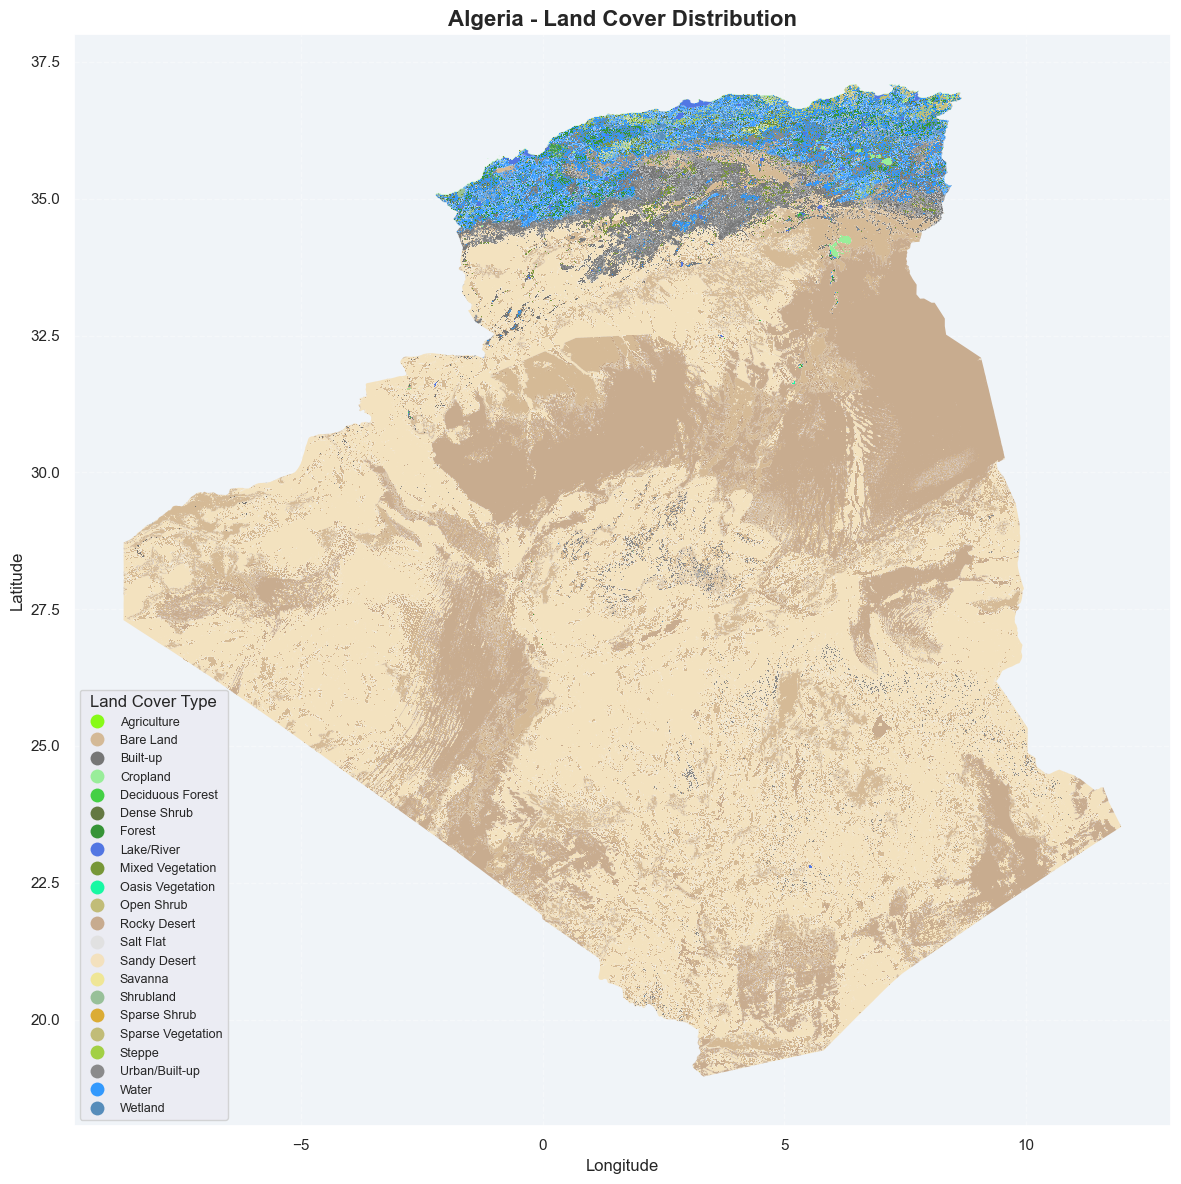


✓ Algeria land cover map generated!


In [9]:
print("="*70)
print("GEOGRAPHIC VISUALIZATION - ALGERIA LAND COVER MAP")
print("="*70)

# Create labeled version for plotting
algeria_lc_clean['lc_label'] = algeria_lc_clean['landcover'].apply(get_lc_label)

# Create custom colormap based on unique labels
unique_labels_alg = algeria_lc_clean['lc_label'].unique()
color_list_alg = [get_lc_color(label) for label in sorted(unique_labels_alg)]
cmap_alg = ListedColormap(color_list_alg)

# Create a comprehensive map for Algeria
fig, ax = plt.subplots(figsize=(14, 12))

# Plot Algeria land cover with legend
algeria_lc_clean.plot(column='lc_label', 
                      ax=ax, 
                      legend=True, 
                      legend_kwds={'title': 'Land Cover Type', 'loc': 'lower left', 'fontsize': 9},
                      cmap=cmap_alg,
                      edgecolor='none',
                      linewidth=0.05,
                      alpha=0.9)

ax.set_title('Algeria - Land Cover Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_facecolor('#f0f4f8')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n✓ Algeria land cover map generated!")
print("="*70)

GEOGRAPHIC VISUALIZATION - TUNISIA LAND COVER MAP


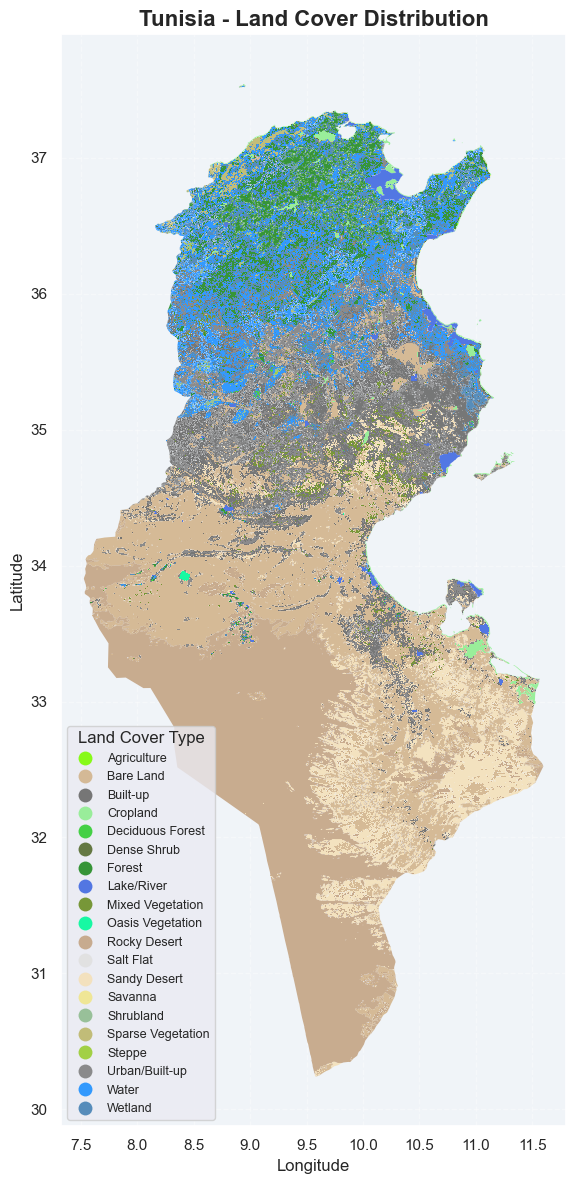


✓ Tunisia land cover map generated!


In [10]:
print("="*70)
print("GEOGRAPHIC VISUALIZATION - TUNISIA LAND COVER MAP")
print("="*70)

# Create labeled version for plotting
tunisia_lc_clean['lc_label'] = tunisia_lc_clean['landcover'].apply(get_lc_label)

# Create custom colormap based on unique labels
unique_labels_tun = tunisia_lc_clean['lc_label'].unique()
color_list_tun = [get_lc_color(label) for label in sorted(unique_labels_tun)]
cmap_tun = ListedColormap(color_list_tun)

# Create a comprehensive map for Tunisia
fig, ax = plt.subplots(figsize=(10, 12))

# Plot Tunisia land cover with legend
tunisia_lc_clean.plot(column='lc_label', 
                      ax=ax, 
                      legend=True, 
                      legend_kwds={'title': 'Land Cover Type', 'loc': 'lower left', 'fontsize': 9},
                      cmap=cmap_tun,
                      edgecolor='none',
                      linewidth=0.05,
                      alpha=0.9)

ax.set_title('Tunisia - Land Cover Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_facecolor('#f0f4f8')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n✓ Tunisia land cover map generated!")
print("="*70)

### 4.2 Combined Map - Algeria & Tunisia

COMBINED MAP - ALGERIA & TUNISIA LAND COVER


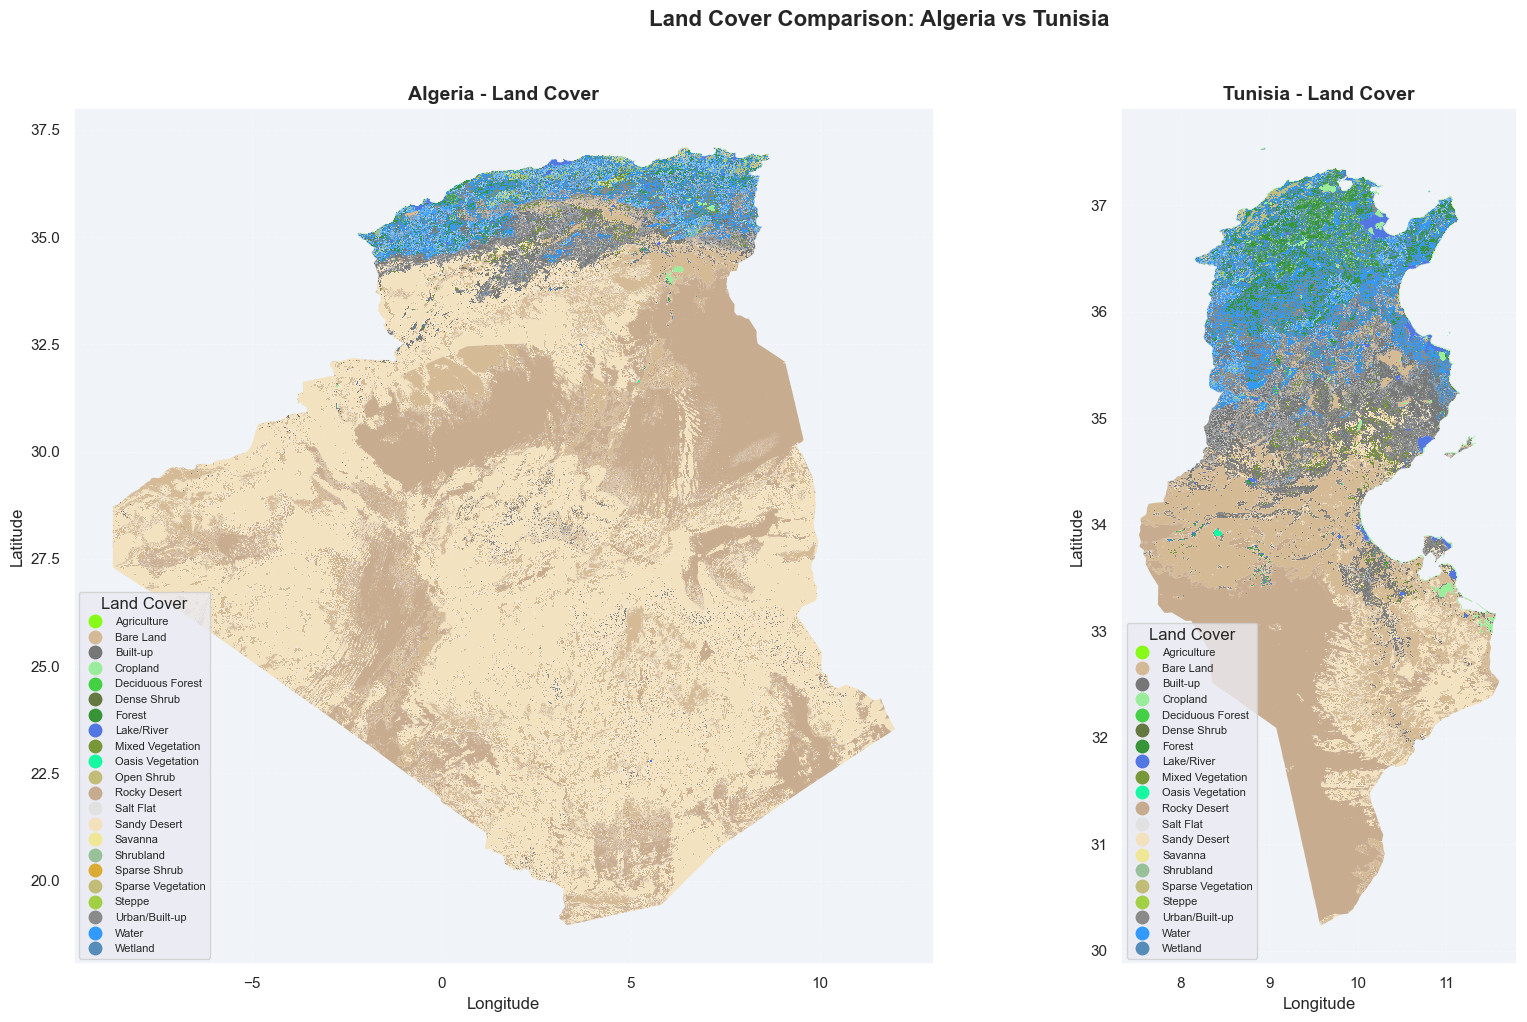


✓ Combined map generated!


In [11]:
print("="*70)
print("COMBINED MAP - ALGERIA & TUNISIA LAND COVER")
print("="*70)

# Ensure labels exist
if 'lc_label' not in algeria_lc_clean.columns:
    algeria_lc_clean['lc_label'] = algeria_lc_clean['landcover'].apply(get_lc_label)
if 'lc_label' not in tunisia_lc_clean.columns:
    tunisia_lc_clean['lc_label'] = tunisia_lc_clean['landcover'].apply(get_lc_label)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Algeria
ax1 = axes[0]
unique_labels_alg = algeria_lc_clean['lc_label'].unique()
color_list_alg = [get_lc_color(label) for label in sorted(unique_labels_alg)]
cmap_alg = ListedColormap(color_list_alg)

algeria_lc_clean.plot(column='lc_label', 
                      ax=ax1, 
                      legend=True, 
                      legend_kwds={'title': 'Land Cover', 'loc': 'lower left', 'fontsize': 8},
                      cmap=cmap_alg,
                      edgecolor='none',
                      linewidth=0.05,
                      alpha=0.9)
ax1.set_title('Algeria - Land Cover', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_facecolor('#f0f4f8')
ax1.grid(True, linestyle='--', alpha=0.3)

# Tunisia
ax2 = axes[1]
unique_labels_tun = tunisia_lc_clean['lc_label'].unique()
color_list_tun = [get_lc_color(label) for label in sorted(unique_labels_tun)]
cmap_tun = ListedColormap(color_list_tun)

tunisia_lc_clean.plot(column='lc_label', 
                      ax=ax2, 
                      legend=True, 
                      legend_kwds={'title': 'Land Cover', 'loc': 'lower left', 'fontsize': 8},
                      cmap=cmap_tun,
                      edgecolor='none',
                      linewidth=0.05,
                      alpha=0.9)
ax2.set_title('Tunisia - Land Cover', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_facecolor('#f0f4f8')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Land Cover Comparison: Algeria vs Tunisia', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Combined map generated!")
print("="*70)

---
## Section 5: Save Results

In [12]:
print("="*70)
print("SAVING RESULTS")
print("="*70)

# Define results directory using config paths
from config import ALGERIA_LC_CLEAN, TUNISIA_LC_CLEAN

# Save cleaned land cover data
algeria_lc_clean.to_file(ALGERIA_LC_CLEAN, driver='GeoJSON')
tunisia_lc_clean.to_file(TUNISIA_LC_CLEAN, driver='GeoJSON')

print(f"\n✓ Saved Algeria land cover: {ALGERIA_LC_CLEAN}")
print(f"  Records: {len(algeria_lc_clean)}")
print(f"  Land cover types: {algeria_lc_clean['landcover'].nunique()}")

print(f"\n✓ Saved Tunisia land cover: {TUNISIA_LC_CLEAN}")
print(f"  Records: {len(tunisia_lc_clean)}")
print(f"  Land cover types: {tunisia_lc_clean['landcover'].nunique()}")

# Summary
print("\n" + "="*70)
print("ANALYSIS COMPLETE - SUMMARY")
print("="*70)
print(f"\nAlgeria Land Cover Dataset:")
print(f"  • Total records: {len(algeria_lc_clean):,}")
print(f"  • Land cover types: {algeria_lc_clean['landcover'].nunique()}")
print(f"  • Geometry type: {algeria_lc_clean.geom_type.unique().tolist()}")
print(f"  • CRS: {algeria_lc_clean.crs}")

print(f"\nTunisia Land Cover Dataset:")
print(f"  • Total records: {len(tunisia_lc_clean):,}")
print(f"  • Land cover types: {tunisia_lc_clean['landcover'].nunique()}")
print(f"  • Geometry type: {tunisia_lc_clean.geom_type.unique().tolist()}")
print(f"  • CRS: {tunisia_lc_clean.crs}")

print(f"\nOutput Files:")
print(f"  • {ALGERIA_LC_CLEAN.name}")
print(f"  • {TUNISIA_LC_CLEAN.name}")

print("\n" + "="*70)
print("✓ ALL PROCESSING COMPLETE!")
print("="*70)


SAVING RESULTS

✓ Saved Algeria land cover: C:\Users\Azur\Downloads\TP\DM\results\data\algeria_landcover_clean.geojson
  Records: 386454
  Land cover types: 22

✓ Saved Tunisia land cover: C:\Users\Azur\Downloads\TP\DM\results\data\tunisia_landcover_clean.geojson
  Records: 52059
  Land cover types: 20

ANALYSIS COMPLETE - SUMMARY

Algeria Land Cover Dataset:
  • Total records: 386,454
  • Land cover types: 22
  • Geometry type: ['Polygon']
  • CRS: EPSG:4326

Tunisia Land Cover Dataset:
  • Total records: 52,059
  • Land cover types: 20
  • Geometry type: ['Polygon']
  • CRS: EPSG:4326

Output Files:
  • algeria_landcover_clean.geojson
  • tunisia_landcover_clean.geojson

✓ ALL PROCESSING COMPLETE!


---
## Section 6: Create Merged Shapefile with Vegetation Classification

This section creates a combined Algeria + Tunisia shapefile with vegetation/desert classification for use in weighted point sampling in `fire.ipynb`.

In [13]:
print("="*70)
print("SECTION 6: CREATE MERGED SHAPEFILE WITH VEGETATION CLASSIFICATION")
print("="*70)

from config import MERGED_LC_CLEAN

# =====================================================
# 6.1 Define Vegetation vs Desert/Barren Classification
# =====================================================
# Based on LC_LABELS defined earlier, classify each land cover type

VEGETATION_TYPES = {
    # Vegetation-rich types (forests, cropland, shrubland)
    'Cropland', 'Sparse Vegetation', 'Shrubland', 'Forest', 'Steppe',
    'Mixed Vegetation', 'Sparse Shrub', 'Agriculture', 'Dense Shrub',
    'Savanna', 'Deciduous Forest', 'Open Shrub', 'Oasis Vegetation'
}

DESERT_BARREN_TYPES = {
    # Desert/barren types (sand, rock, bare land)
    'Bare Land', 'Sandy Desert', 'Rocky Desert', 'Salt Flat'
}

WATER_URBAN_TYPES = {
    # Water and urban types (exclude from sampling)
    'Water', 'Wetland', 'Lake/River', 'Urban/Built-up', 'Built-up', 'Urban Mix'
}

def classify_landcover(lc_label):
    """
    Classify land cover label into vegetation category.
    Returns: 'vegetation', 'desert', 'water_urban', or 'unknown'
    """
    if lc_label in VEGETATION_TYPES:
        return 'vegetation'
    elif lc_label in DESERT_BARREN_TYPES:
        return 'desert'
    elif lc_label in WATER_URBAN_TYPES:
        return 'water_urban'
    else:
        # For unknown types, check if name contains vegetation-related words
        lc_lower = lc_label.lower()
        if any(v in lc_lower for v in ['forest', 'crop', 'vegetation', 'shrub', 'grass', 'agri']):
            return 'vegetation'
        elif any(d in lc_lower for d in ['desert', 'bare', 'sand', 'rock', 'barren', 'salt']):
            return 'desert'
        else:
            return 'unknown'

# =====================================================
# 6.2 Apply Classification to Both Countries
# =====================================================
print("\n--- 6.1 Applying vegetation classification ---")

# Ensure lc_label column exists
if 'lc_label' not in algeria_lc_clean.columns:
    algeria_lc_clean['lc_label'] = algeria_lc_clean['landcover'].apply(get_lc_label)
if 'lc_label' not in tunisia_lc_clean.columns:
    tunisia_lc_clean['lc_label'] = tunisia_lc_clean['landcover'].apply(get_lc_label)

# Apply classification
algeria_lc_clean['lc_category'] = algeria_lc_clean['lc_label'].apply(classify_landcover)
tunisia_lc_clean['lc_category'] = tunisia_lc_clean['lc_label'].apply(classify_landcover)

print("\nAlgeria land cover category distribution:")
print(algeria_lc_clean['lc_category'].value_counts())

print("\nTunisia land cover category distribution:")
print(tunisia_lc_clean['lc_category'].value_counts())

# =====================================================
# 6.3 Merge Algeria and Tunisia Shapefiles
# =====================================================
print("\n--- 6.2 Merging Algeria and Tunisia shapefiles ---")

# Ensure same CRS
if tunisia_lc_clean.crs != algeria_lc_clean.crs:
    tunisia_lc_clean = tunisia_lc_clean.to_crs(algeria_lc_clean.crs)
    print(f"  Tunisia CRS converted to: {algeria_lc_clean.crs}")

# Select columns to keep for merging
cols_to_keep = ['landcover', 'lc_label', 'lc_category', 'country', 'geometry']

# Ensure country column exists
if 'country' not in algeria_lc_clean.columns:
    algeria_lc_clean['country'] = 'Algeria'
if 'country' not in tunisia_lc_clean.columns:
    tunisia_lc_clean['country'] = 'Tunisia'

# Merge datasets
merged_lc = gpd.GeoDataFrame(
    pd.concat([
        algeria_lc_clean[cols_to_keep],
        tunisia_lc_clean[cols_to_keep]
    ], ignore_index=True),
    crs=algeria_lc_clean.crs
)

print(f"\nMerged shapefile created:")
print(f"  Total polygons: {len(merged_lc):,}")
print(f"  Algeria polygons: {(merged_lc['country'] == 'Algeria').sum():,}")
print(f"  Tunisia polygons: {(merged_lc['country'] == 'Tunisia').sum():,}")

print(f"\nMerged category distribution:")
print(merged_lc['lc_category'].value_counts())

# =====================================================
# 6.4 Calculate Area-Based Statistics
# =====================================================
print("\n--- 6.3 Calculating area statistics ---")

# Calculate area for each polygon (in square meters for projected CRS, or degrees for geographic)
merged_lc['area'] = merged_lc.geometry.area

# Summarize by category
category_stats = merged_lc.groupby('lc_category').agg({
    'area': ['sum', 'count', 'mean']
}).round(2)
category_stats.columns = ['total_area', 'polygon_count', 'mean_area']
category_stats['area_percent'] = (category_stats['total_area'] / category_stats['total_area'].sum() * 100).round(2)

print("\nArea statistics by category:")
print(category_stats)

# =====================================================
# 6.5 Save Merged Shapefile
# =====================================================
print("\n--- 6.4 Saving merged shapefile ---")

# Save to GeoJSON
merged_lc.to_file(MERGED_LC_CLEAN, driver='GeoJSON')
print(f"\n✓ Merged shapefile saved to: {MERGED_LC_CLEAN}")
print(f"  Records: {len(merged_lc):,}")
print(f"  Categories: {merged_lc['lc_category'].unique().tolist()}")

print("\n" + "="*70)
print("✓ MERGED SHAPEFILE CREATION COMPLETE!")
print("="*70)

SECTION 6: CREATE MERGED SHAPEFILE WITH VEGETATION CLASSIFICATION

--- 6.1 Applying vegetation classification ---

Algeria land cover category distribution:
lc_category
desert         250484
water_urban     96678
vegetation      39292
Name: count, dtype: int64

Tunisia land cover category distribution:
lc_category
water_urban    32294
vegetation     10171
desert          9594
Name: count, dtype: int64

--- 6.2 Merging Algeria and Tunisia shapefiles ---

Merged shapefile created:
  Total polygons: 438,513
  Algeria polygons: 386,454
  Tunisia polygons: 52,059

Merged category distribution:
lc_category
desert         260078
water_urban    128972
vegetation      49463
Name: count, dtype: int64

--- 6.3 Calculating area statistics ---


C:\Users\Azur\AppData\Local\Temp\ipykernel_13056\1022274627.py:113: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged_lc['area'] = merged_lc.geometry.area



Area statistics by category:
             total_area  polygon_count  mean_area  area_percent
lc_category                                                    
desert           200.40         260078        0.0         87.66
vegetation         5.02          49463        0.0          2.20
water_urban       23.18         128972        0.0         10.14

--- 6.4 Saving merged shapefile ---

✓ Merged shapefile saved to: C:\Users\Azur\Downloads\TP\DM\results\data\merged_landcover_clean.geojson
  Records: 438,513
  Categories: ['vegetation', 'water_urban', 'desert']

✓ MERGED SHAPEFILE CREATION COMPLETE!


VISUALIZING MERGED LAND COVER BY CATEGORY


C:\Users\Azur\AppData\Local\Temp\ipykernel_13056\4240951682.py:28: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax1.legend(loc='lower left', fontsize=10)
C:\Users\Azur\AppData\Local\Temp\ipykernel_13056\4240951682.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='lower left', fontsize=10)
C:\Users\Azur\AppData\Local\Temp\ipykernel_13056\4240951682.py:42: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax2.legend(loc='lower left', fontsize=10)
C:\Users\Azur\AppData\Local\Temp\ipykernel_13056\4240951682.py:42: UserWarning: No artists with labels found to put in 

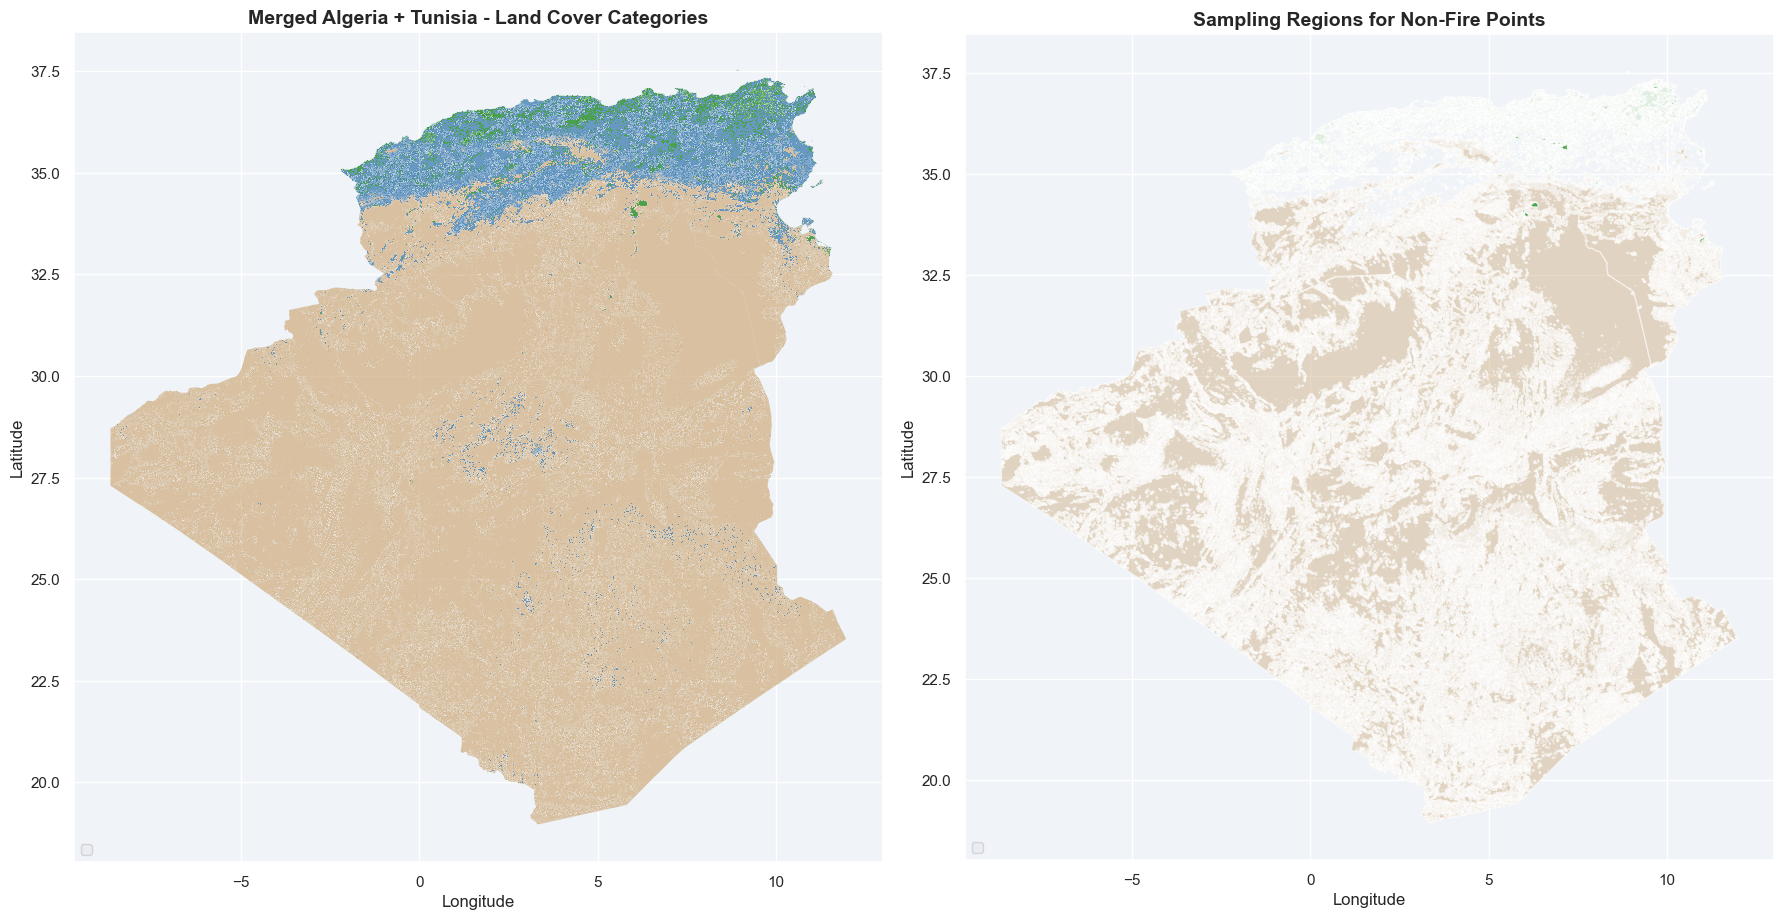


Sampling regions summary:
  Vegetation polygons: 49,463 (16.0%)
  Desert/Barren polygons: 260,078 (84.0%)
  Water/Urban (excluded): 128,972

✓ Visualization complete!


In [14]:
# =====================================================
# 6.6 Visualize Merged Land Cover by Category
# =====================================================
print("="*70)
print("VISUALIZING MERGED LAND COVER BY CATEGORY")
print("="*70)

# Define category colors
CATEGORY_COLORS = {
    'vegetation': '#228B22',    # Forest Green
    'desert': '#D2B48C',        # Tan
    'water_urban': '#4682B4',   # Steel Blue
    'unknown': '#808080'        # Gray
}

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Left: Full merged map colored by category
ax1 = axes[0]
for category, color in CATEGORY_COLORS.items():
    subset = merged_lc[merged_lc['lc_category'] == category]
    if len(subset) > 0:
        subset.plot(ax=ax1, color=color, alpha=0.8, label=category, edgecolor='none')

ax1.set_title('Merged Algeria + Tunisia - Land Cover Categories', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.legend(loc='lower left', fontsize=10)
ax1.set_facecolor('#f0f4f8')

# Right: Vegetation only (for fire sampling)
ax2 = axes[1]
vegetation_mask = merged_lc['lc_category'] == 'vegetation'
desert_mask = merged_lc['lc_category'] == 'desert'

merged_lc[vegetation_mask].plot(ax=ax2, color='#228B22', alpha=0.8, label='Vegetation (85-90%)')
merged_lc[desert_mask].plot(ax=ax2, color='#D2B48C', alpha=0.5, label='Desert/Oasis (10-15%)')

ax2.set_title('Sampling Regions for Non-Fire Points', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.legend(loc='lower left', fontsize=10)
ax2.set_facecolor('#f0f4f8')

plt.tight_layout()
plt.show()

# Print sampling summary
veg_count = vegetation_mask.sum()
desert_count = desert_mask.sum()
total_count = veg_count + desert_count

print(f"\nSampling regions summary:")
print(f"  Vegetation polygons: {veg_count:,} ({100*veg_count/total_count:.1f}%)")
print(f"  Desert/Barren polygons: {desert_count:,} ({100*desert_count/total_count:.1f}%)")
print(f"  Water/Urban (excluded): {(~vegetation_mask & ~desert_mask).sum():,}")
print("\n✓ Visualization complete!")